In [1]:
# import key libraries
import numpy as np
import matplotlib.pyplot as plt
import requests

# PyTorch libraries
import torch
import torch.nn.functional as F

# Hugging Face libraries
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2Tokenizer
from datasets import load_dataset



In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
import torch

# Load small GPT2 pre-trained model and tokenizer
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

try:
    gpt2 = AutoModelForCausalLM.from_pretrained('gpt2').to(device)
    print(f"Model loaded successfully to {device}")
except Exception as e:
    print(f"Failed to load model to {device}: {e}. Attempting to load to CPU instead.")
    # If loading to the current 'device' (likely CUDA) failed, switch to CPU
    device = torch.device('cpu')
    gpt2 = AutoModelForCausalLM.from_pretrained('gpt2').to(device)
    print("Model successfully loaded to CPU.")

gpt2.eval();

# Set pad_token_id for both tokenizer and model to handle varying sequence lengths
tokenizer.pad_token = tokenizer.eos_token
gpt2.config.pad_token_id = gpt2.config.eos_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Model loaded successfully to cuda


In [4]:
def calculate_perplexity(tokens: torch.tensor,
                   model: torch.nn.Module=gpt2,
                   seq_length: int=1024,
                   device: str=device
                   ) -> float:

    total_len = torch.numel(tokens)
    if total_len == 0:
        return float('inf') # Return infinity for empty input

    sum_losses = 0.
    num_effective_segments = 0

    if total_len < seq_length: # Handle sequences shorter than one full segment
        # Process the entire short sequence as one segment
        X = tokens.to(device) # tokens is (1, N), model can handle this directly
        with torch.no_grad():
            output = model(X, labels=X)
        sum_losses += output.loss.item()
        num_effective_segments = 1 # Count this as one segment for averaging
    else: # Process in full segments
        num_segments = total_len // seq_length
        for i in range(num_segments):
            start = i * seq_length
            end = start + seq_length
            # Extract a sequence of tokens and add batch dimension
            X = tokens[0,start:end].unsqueeze(0).to(device)
            with torch.no_grad():
                output = model(X, labels=X)
            sum_losses += output.loss.item()
        num_effective_segments = num_segments

    if num_effective_segments == 0: # Should not happen if total_len > 0, but as a safeguard
        return float('inf')

    # Calculate perplexity
    perplexity = torch.exp(torch.tensor(sum_losses)/num_effective_segments)

    return perplexity

In [5]:
# Use a short sample text to test the perplexity calculation function
sample_text = "This is a short sample text to test the perplexity calculation function."
tokens_from_text = tokenizer(sample_text, return_tensors='pt')['input_ids']

# test the perplexity
perplxity = calculate_perplexity(tokens_from_text)
print(f'Perplexity for sample text: {perplxity:.4f}')

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity for sample text: 130.6021


# Calculate a group of books downloaded from Gutenberg

In [6]:
# all books have the same url format; they are unique by numerical code
baseurl='https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

In [7]:
ppls = np.zeros(len(bookurls))

for i, (code, title) in enumerate(bookurls):
  fullurl = baseurl + code + '/pg' + code + '.txt'
  text = requests.get(fullurl).text

  tokens = tokenizer(text, return_tensors='pt', truncation=True, max_length=50000)['input_ids']

  # Move the correctly shaped (1, N) tokens tensor to the device
  tokens = tokens.to(device)

  ppls[i] = calculate_perplexity(tokens)
  print(f'{title}: {ppls[i]:.4f}')

Frankenstein: 197.8153
GreatGatsby: 150.5650
AliceWonderland: 94.9893
RomeoJuliet: 269.7297
HuckFinn: 148.0950
HeartDarkness: 174.6845
GrimmsTales: 94.3479
EdgarAllenPoe: 65.6742
WarOfTheWorlds: 213.2494
GulliversTravels: 163.3496


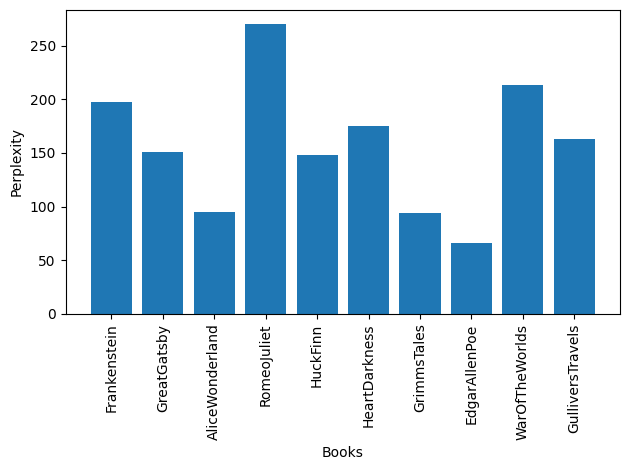

In [15]:
# Visualize
plt.bar(np.arange(len(bookurls)),ppls)
ax = plt.gca()
ax.set(xlabel='Books', ylabel='Perplexity', xticks=np.arange(len(bookurls)))
ax.set_xticklabels([title for _, title in bookurls], rotation=90, ha='center')
plt.tight_layout()
plt.show()

# Explore perplexities for different models

In [16]:
# Import text from wikipedia
text = load_dataset('wikitext','wikitext-2-raw-v1',split='test')
tokens = tokenizer.encode('\n'.join(text['text'][:2000]),return_tensors='pt').to(device)
torch.numel(tokens)

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (136702 > 1024). Running this sequence through the model will result in indexing errors


136702

In [19]:
print(f'Wikitext dataset has perplexity: {calculate_perplexity(tokens):.3f}')

Wikitext dataset has perplexity: 29.773


In [20]:
# dictionary of modelname:identifier
model_ids = {
    'small':  'gpt2',        # 124M
    'medium': 'gpt2-medium', # 355M
    'large':  'gpt2-large',  # 774M
    'xl':     'gpt2-xl'      # 1.6B
}

# load all models into a dictionary
models = {}
for name, id in model_ids.items():
  models[name] = AutoModelForCausalLM.from_pretrained(id).to(device)
  models[name].eval()

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [22]:
# Calculate perplexities for different models
ppls = np.zeros(len(models))
for i,(name, model) in enumerate(models.items()):
  ppls[i] = calculate_perplexity(tokens, model=model)
  print(f'{name}: {ppls[i]:.3f}')

small: 29.773
medium: 21.401
large: 18.704
xl: 16.908


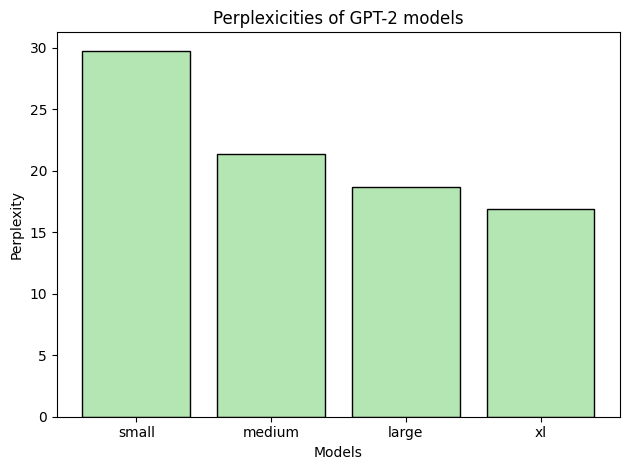

In [27]:
# Visualize
plt.bar(np.arange(len(models)),ppls, color=[.7,.9,.7], edgecolor='k')
ax = plt.gca()
ax.set(xlabel='Models', ylabel='Perplexity', xticks=np.arange(len(models)), title='Perplexicities of GPT-2 models')
ax.set_xticklabels([name for name in models.keys()], rotation=0, ha='center')
plt.tight_layout()
plt.show()

# Explore perplexities of different sequence lengths

In [28]:
seq_length = [32, 64, 128, 256, 512, 1024]
ppl = np.zeros(len(seq_length))

for i, seq in enumerate(seq_length):
  ppl[i] = calculate_perplexity(tokens, model=gpt2, seq_length=seq)
  print(f'Perplexity for sequence length {seq}: {ppl[i]:.3f}')


Perplexity for sequence length 32: 146.426
Perplexity for sequence length 64: 89.491
Perplexity for sequence length 128: 60.553
Perplexity for sequence length 256: 44.907
Perplexity for sequence length 512: 35.516
Perplexity for sequence length 1024: 29.773


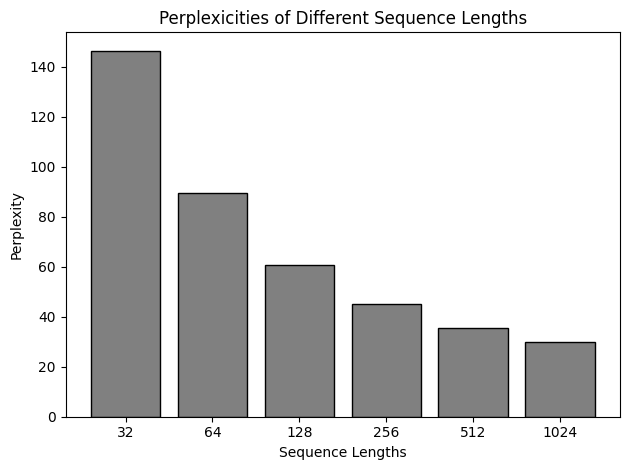

In [44]:
# Visualize
plt.bar(np.arange(len(seq_length)),ppl, color=[.5,.5,.5], edgecolor='k')
ax = plt.gca()
ax.set(xlabel='Sequence Lengths', ylabel='Perplexity', xticks=np.arange(len(seq_length)), title='Perplexicities of Different Sequence Lengths')
ax.set_xticklabels([seq for seq in seq_length], rotation=0, ha='center')
plt.tight_layout()
plt.show()